# প্রকল্প ০৩: গ্রাহক সেগমেন্টেশন
## 🛍️ কে-মিন্স ক্লাস্টারিং

### 🎪 গল্প দিয়ে শুরু করি

**মনে করো,** তুমি একটি বড় শপিং মলের মালিক। তোমার মলে অনেক গ্রাহক আসে:
- কেউ বেশি টাকা খরচ করে, কেউ কম
- কেউ তরুণ, কেউ বয়স্ক
- কেউ প্রতিদিন আসে, কেউ মাসে একবার

তুমি যদি গ্রাহকদের **গ্রুপে ভাগ** করতে পারো, তাহলে প্রতিটি গ্রুপের জন্য আলাদা অফার দিতে পারবে! যেমন:
- **গ্রুপ ১:** তরুণ + কম আয় + বেশি খরচ → তাদের জন্য ছাড়ের অফার
- **গ্রুপ ২:** বয়স্ক + বেশি আয় + কম খরচ → তাদের জন্য ভিআইপি সার্ভিস

**এটাই ক্লাস্টারিং!** কম্পিউটার নিজে থেকেই গ্রাহকদের গ্রুপে ভাগ করে ফেলে — আমাদের কিছু না বলেই!

## 📂 ডেটা লোড ও এক্সপ্লোরেশন

In [1]:
# লাইব্রেরি ইম্পোর্ট
import pandas as pd  # ডেটা হ্যান্ডলিং
import numpy as np  # গণিত
import matplotlib.pyplot as plt  # গ্রাফ
import seaborn as sns  # সুন্দর গ্রাফ
from sklearn.cluster import KMeans  # কে-মিন্স ক্লাস্টারিং
from sklearn.preprocessing import StandardScaler  # ডেটা স্কেলিং
from sklearn.metrics import silhouette_score  # সিলুয়েট স্কোর

# ডেটা লোড
df = pd.read_csv('mall_customers.csv')
print('ডেটার প্রথম ৫ সারি:')
display(df.head())
print(f'\nমোট গ্রাহক: {len(df)}')


ডেটার প্রথম ৫ সারি:


,customer_id,age,annual_income,spending_score
0,1,52,27.0,79.0
1,2,18,24.0,81.0
2,3,38,28.0,86.0
3,4,65,33.0,86.0
4,5,23,24.0,61.0



মোট গ্রাহক: 200


In [2]:
# ডেটার সাধারণ তথ্য
print('=== ডেটার তথ্য ===')
print(df.info())
print('\n=== পরিসংখ্যান ===')
display(df.describe())
print('\n=== নাল ভ্যালু চেক ===')
print(df.isnull().sum())

=== ডেটার তথ্য ===
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customer_id     200 non-null    int64  
 1   age             200 non-null    int64  
 2   annual_income   200 non-null    float64
 3   spending_score  200 non-null    float64
dtypes: float64(2), int64(2)
memory usage: 6.4 KB
None

=== পরিসংখ্যান ===


,customer_id,age,annual_income,spending_score
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,42.750000,54.530000,49.560000
std,57.879185,15.350757,22.963355,22.760196
min,1.000000,18.000000,15.000000,4.000000
25%,50.750000,30.750000,29.000000,28.750000
50%,100.500000,42.500000,55.000000,49.500000
75%,150.250000,55.250000,76.000000,68.000000
max,200.000000,69.000000,94.000000,100.000000



=== নাল ভ্যালু চেক ===
customer_id       0
age               0
annual_income     0
spending_score    0
dtype: int64


C:\Users\hp\AppData\Local\Temp\ipykernel_15500\2426134336.py:19: UserWarning: Glyph 2476 (\N{BENGALI LETTER BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_15500\2426134336.py:19: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_15500\2426134336.py:19: UserWarning: Glyph 2479 (\N{BENGALI LETTER YA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_15500\2426134336.py:19: UserWarning: Glyph 2492 (\N{BENGALI SIGN NUKTA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_15500\2426134336.py:19: UserWarning: Glyph 2488 (\N{BENGALI LETTER SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_15500\2426134336.py:19: UserWarning: Glyph 2495 (\N{BENGALI VOWEL SIGN I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2476 (\N{BENGALI LETTER BA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2479 (\N{BENGALI LETTER YA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2492 (\N{BENGALI SIGN NUKTA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWa

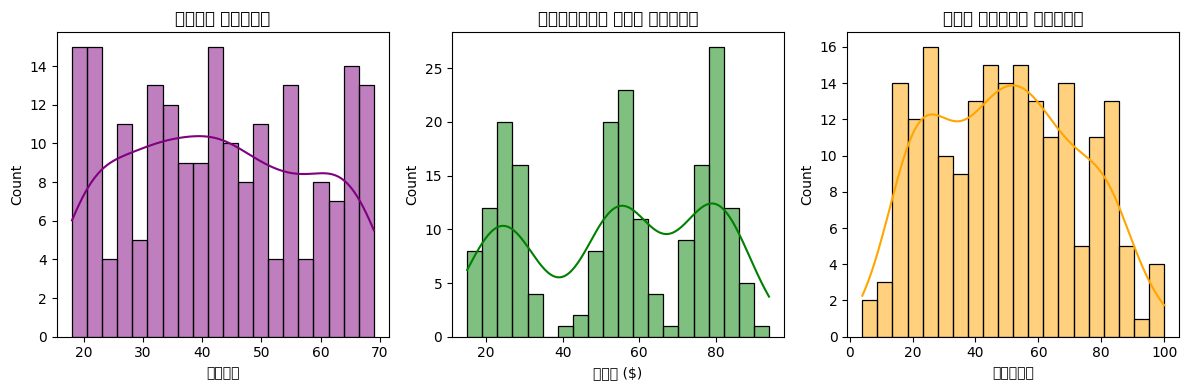

In [3]:
# ডেটা ভিজুয়ালাইজেশন
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.histplot(df['age'], bins=20, kde=True, color='purple')
plt.title('বয়স বিতরণ')
plt.xlabel('বয়স')

plt.subplot(1, 3, 2)
sns.histplot(df['annual_income'], bins=20, kde=True, color='green')
plt.title('বার্ষিক আয় বিতরণ')
plt.xlabel('আয় ($)')

plt.subplot(1, 3, 3)
sns.histplot(df['spending_score'], bins=20, kde=True, color='orange')
plt.title('খরচ স্কোর বিতরণ')
plt.xlabel('স্কোর')

plt.tight_layout()
plt.show()

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2457 (\N{BENGALI LETTER NGA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


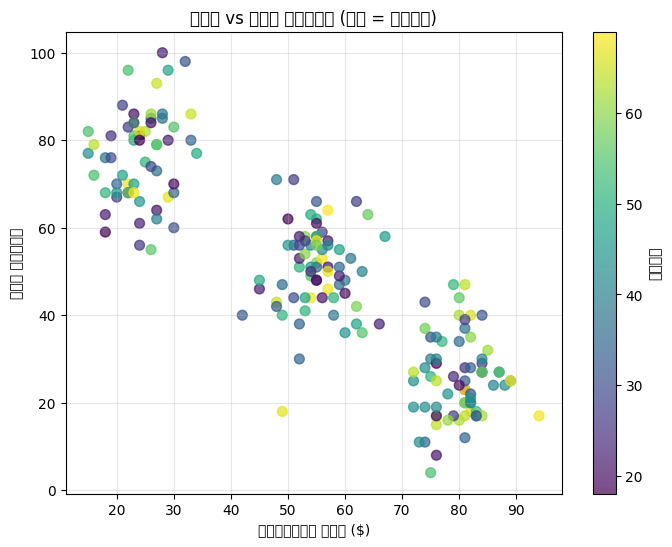

In [4]:
# আয় ও খরচের সম্পর্ক দেখা যাক
plt.figure(figsize=(8, 6))
scatter = plt.scatter(df['annual_income'], df['spending_score'],
                      c=df['age'], cmap='viridis', alpha=0.7, s=50)
plt.colorbar(scatter, label='বয়স')
plt.title('আয় vs খরচ স্কোর (রঙ = বয়স)')
plt.xlabel('বার্ষিক আয় ($)')
plt.ylabel('খরচ স্কোর')
plt.grid(True, alpha=0.3)
plt.show()

## 🔧 ডেটা প্রস্তুতি ও স্কেলিং
ক্লাস্টারিংয়ের আগে ডেটা স্কেল করা জরুরি — নাহলে বড় সংখ্যার কলাম ছোট সংখ্যার কলামকে চাপ দিয়ে ফেলবে।

In [5]:
# ক্লাস্টারিং এর জন্য ফিচার নির্বাচন
features = df[['annual_income', 'spending_score']]  # দুটো ফিচার নিচ্ছি

# ডেটা স্কেলিং
scaler = StandardScaler()  # স্কেলার অবজেক্ট
X_scaled = scaler.fit_transform(features)  # ডেটা স্কেল করা

print('স্কেল করার আগে:')
print(f'আয়: গড়={features["annual_income"].mean():.1f}, std={features["annual_income"].std():.1f}')
print(f'স্কোর: গড়={features["spending_score"].mean():.1f}, std={features["spending_score"].std():.1f}')
print('\n✅ এখন দুটো ফিচারই সমান স্কেলে আছে!')

স্কেল করার আগে:
আয়: গড়=54.5, std=23.0
স্কোর: গড়=49.6, std=22.8

✅ এখন দুটো ফিচারই সমান স্কেলে আছে!


## 👇 এলবো পদ্ধতি (Elbow Method)
কতগুলো ক্লাস্টার নেওয়া উচিত? এলবো পদ্ধতি তা খুঁজে বের করতে সাহায্য করে।

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2439 (\N{BENGALI LETTER I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2472 (\N{BENGALI LETTER NA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarn

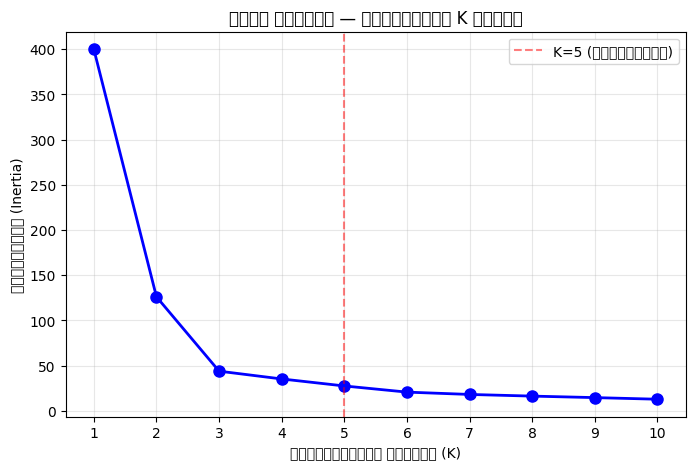

📌 এলবো গ্রাফে যেখানে হাতের কনুইয়ের মত বাঁক আছে, সেটাই সেরা K।
এখানে K=5 সেরা মনে হচ্ছে!


In [6]:
# এলবো পদ্ধতি — বিভিন্ন K এর জন্য ইনর্শিয়া
inertias = []  # ইনর্শিয়া মান সংরক্ষণ
K_range = range(1, 11)  # ১ থেকে ১০ টি ক্লাস্টার

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)  # ইনর্শিয়া (দূরত্বের সমষ্টি)

# এলবো গ্রাফ
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('ক্লাস্টারের সংখ্যা (K)')
plt.ylabel('ইনর্শিয়া (Inertia)')
plt.title('এলবো পদ্ধতি — সর্বোত্তম K খোঁজা')
plt.axvline(x=5, color='red', linestyle='--', alpha=0.5, label='K=5 (সর্বোত্তম)')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print('📌 এলবো গ্রাফে যেখানে হাতের কনুইয়ের মত বাঁক আছে, সেটাই সেরা K।\nএখানে K=5 সেরা মনে হচ্ছে!')

K=2: সিলুয়েট স্কোর = 0.5900
K=3: সিলুয়েট স্কোর = 0.6351


K=4: সিলুয়েট স্কোর = 0.5790


K=5: সিলুয়েট স্কোর = 0.4878
K=6: সিলুয়েট স্কোর = 0.4453
K=7: সিলুয়েট স্কোর = 0.4256


K=8: সিলুয়েট স্কোর = 0.3899
K=9: সিলুয়েট স্কোর = 0.3722
K=10: সিলুয়েট স্কোর = 0.4066


C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2488 (\N{BENGALI LETTER SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2495 (\N{BENGALI VOWEL SIGN I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2482 (\N{BENGALI LETTER LA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: User

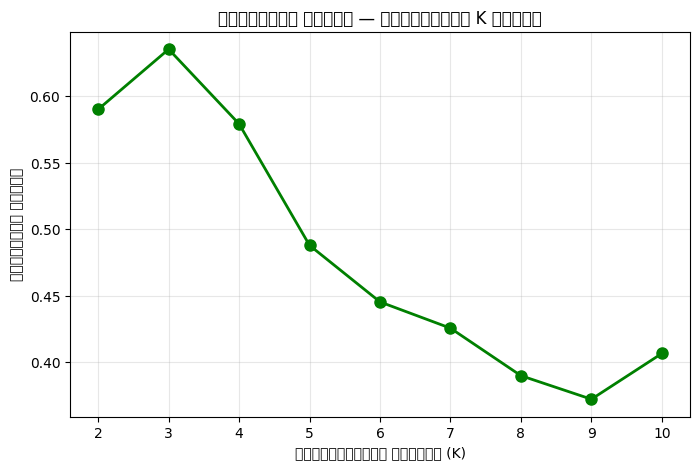


🏆 সেরা K = 3 (সিলুয়েট স্কোর = 0.6351)


In [7]:
# সিলুয়েট স্কোর দিয়েও যাচাই করা যাক
silhouette_scores = []

for k in range(2, 11):  # সিলুয়েট স্কোর কমপক্ষে ২ টি ক্লাস্টার লাগে
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f'K={k}: সিলুয়েট স্কোর = {score:.4f}')

# সিলুয়েট স্কোর গ্রাফ
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, 'go-', linewidth=2, markersize=8)
plt.xlabel('ক্লাস্টারের সংখ্যা (K)')
plt.ylabel('সিলুয়েট স্কোর')
plt.title('সিলুয়েট স্কোর — সর্বোত্তম K খোঁজা')
plt.xticks(range(2, 11))
plt.grid(True, alpha=0.3)
plt.show()

best_k = range(2, 11)[np.argmax(silhouette_scores)]
print(f'\n🏆 সেরা K = {best_k} (সিলুয়েট স্কোর = {max(silhouette_scores):.4f})')

## 🎯 কে-মিন্স মডেল তৈরি
এখন আমরা সবচেয়ে ভালো K (৫) দিয়ে মডেল তৈরি করবো।

In [8]:
# কে-মিন্স মডেল
k = 5  # সেরা ক্লাস্টার সংখ্যা
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)  # ক্লাস্টার লেবেল

# প্রতিটি ক্লাস্টারে কতজন?
print('=== ক্লাস্টার অনুযায়ী গ্রাহক সংখ্যা ===')
print(df['cluster'].value_counts().sort_index())

# ক্লাস্টারগুলোর বৈশিষ্ট্য
print('\n=== ক্লাস্টারের বৈশিষ্ট্য ===')
cluster_stats = df.groupby('cluster')[['age', 'annual_income', 'spending_score']].mean()
display(cluster_stats.round(1))

=== ক্লাস্টার অনুযায়ী গ্রাহক সংখ্যা ===
cluster
0    67
1    51
2    29
3    31
4    22
Name: count, dtype: int64

=== ক্লাস্টারের বৈশিষ্ট্য ===


,age,annual_income,spending_score
cluster,,,
0,41.2,54.8,51.6
1,45.7,79.8,20.7
2,39.5,22.9,67.7
3,42.9,25.5,84.7
4,44.6,77.8,36.9


C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2454 (\N{BENGALI LETTER KHA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2458 (\N{BENGALI LETTER CA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWa

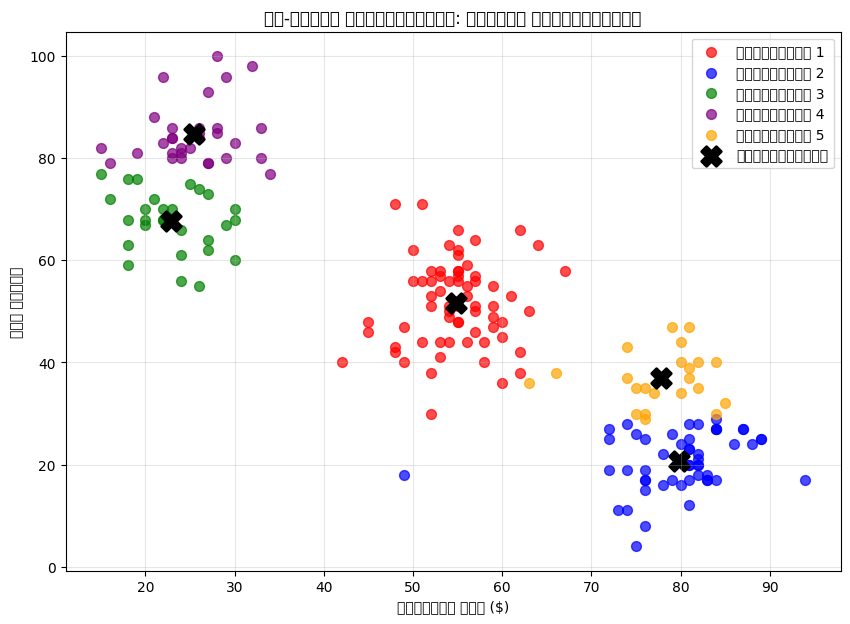

In [9]:
# ক্লাস্টার ভিজুয়ালাইজেশন
plt.figure(figsize=(10, 7))

colors = ['red', 'blue', 'green', 'purple', 'orange']
for i in range(k):
    cluster_data = df[df['cluster'] == i]
    plt.scatter(cluster_data['annual_income'], cluster_data['spending_score'],
                c=colors[i], label=f'ক্লাস্টার {i+1}', alpha=0.7, s=50)

# সেন্ট্রয়েড দেখানো
centroids = scaler.inverse_transform(kmeans.cluster_centers_)  # স্কেল ফিরিয়ে আনা
plt.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='X', s=200,
            linewidths=2, label='সেন্ট্রয়েড')

plt.title('কে-মিন্স ক্লাস্টারিং: গ্রাহক সেগমেন্টেশন')
plt.xlabel('বার্ষিক আয় ($)')
plt.ylabel('খরচ স্কোর')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
# প্রতিটি ক্লাস্টারের নামকরণ
cluster_names = {
    0: '💰 বেশি আয়, বেশি খরচ — ভিআইপি গ্রাহক',
    1: '💰 কম আয়, কম খরচ — সাশ্রয়ী গ্রাহক',
    2: '💰 বেশি আয়, কম খরচ — বিবেচক গ্রাহক',
    3: '💰 কম আয়, বেশি খরচ — ফুর্তিবাজ গ্রাহক',
    4: '💰 মাঝারি আয়, মাঝারি খরচ — সাধারণ গ্রাহক'
}

print('📋 গ্রাহক গ্রুপগুলোর বিবরণ:')
for cluster_id in sorted(cluster_names.keys()):
    count = len(df[df['cluster'] == cluster_id])
    avg_income = df[df['cluster'] == cluster_id]['annual_income'].mean()
    avg_score = df[df['cluster'] == cluster_id]['spending_score'].mean()
    print(f'\nক্লাস্টার {cluster_id + 1}: {cluster_names[cluster_id]}')
    print(f'   গ্রাহক সংখ্যা: {count}টি, গড় আয়: ${avg_income:.0f}, গড় স্কোর: {avg_score:.0f}')

📋 গ্রাহক গ্রুপগুলোর বিবরণ:

ক্লাস্টার 1: 💰 বেশি আয়, বেশি খরচ — ভিআইপি গ্রাহক
   গ্রাহক সংখ্যা: 67টি, গড় আয়: $55, গড় স্কোর: 52

ক্লাস্টার 2: 💰 কম আয়, কম খরচ — সাশ্রয়ী গ্রাহক
   গ্রাহক সংখ্যা: 51টি, গড় আয়: $80, গড় স্কোর: 21

ক্লাস্টার 3: 💰 বেশি আয়, কম খরচ — বিবেচক গ্রাহক
   গ্রাহক সংখ্যা: 29টি, গড় আয়: $23, গড় স্কোর: 68

ক্লাস্টার 4: 💰 কম আয়, বেশি খরচ — ফুর্তিবাজ গ্রাহক
   গ্রাহক সংখ্যা: 31টি, গড় আয়: $25, গড় স্কোর: 85

ক্লাস্টার 5: 💰 মাঝারি আয়, মাঝারি খরচ — সাধারণ গ্রাহক
   গ্রাহক সংখ্যা: 22টি, গড় আয়: $78, গড় স্কোর: 37


## 🎯 তুমি কি শিখলে?

| ধারণা | বাংলায় অর্থ |
|-------|-------------|
| **ক্লাস্টারিং** | একই ধরনের জিনিস একসাথে গ্রুপ করা |
| **কে-মিন্স** | K সংখ্যক গ্রুপে ডেটা ভাগ করার অ্যালগরিদম |
| **এলবো পদ্ধতি** | সেরা K বের করার কৌশল |
| **সিলুয়েট স্কোর** | ক্লাস্টার কতটা ভালো হয়েছে তা মাপে |
| **সেন্ট্রয়েড** | প্রতিটি গ্রুপের মাঝখানের বিন্দু |
| **স্কেলিং** | সব ফিচারকে সমান গুরুত্ব দেওয়ার জন্য ডেটা ছোট-বড় করা |

**মনে রাখবে:** ক্লাস্টারিং এ তত্ত্বাবধান (সুপারভিশন) লাগে না! কম্পিউটার নিজেই গ্রুপ খুঁজে বের করে। ব্যবসায়ীরা এই গ্রুপ ব্যবহার করে বিভিন্ন গ্রাহকের জন্য আলাদা মার্কেটিং করে! 🛍️